In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [4]:
# Manual dataset - 100% kaam karega!
data = {
    'budget':     [237000000, 300000000, 245000000, 150000000,
                   220000000, 178000000, 260000000, 200000000,
                   190000000, 130000000, 100000000, 85000000,
                   75000000, 50000000, 40000000, 30000000,
                   25000000, 20000000, 15000000, 10000000],
    'popularity': [150, 139, 107, 98, 85, 79, 120, 95,
                   88, 72, 65, 58, 52, 45, 38, 32, 28, 22, 18, 12],
    'runtime':    [178, 169, 148, 152, 143, 136, 158, 141,
                   135, 128, 122, 118, 112, 108, 102, 96, 92, 88, 82, 76],
    'vote_count': [15000, 12000, 11000, 9500, 8800, 7600, 13000,
                   9000, 8200, 7000, 6500, 5800, 5200, 4500,
                   3800, 3200, 2800, 2200, 1800, 1200],
    'revenue':    [2788000000, 2068000000, 1670000000, 1516000000,
                   1405000000, 1341000000, 2187000000, 1519000000,
                   1084000000, 896000000, 750000000, 620000000,
                   520000000, 420000000, 320000000, 220000000,
                   150000000, 100000000, 70000000, 40000000],
    'vote_average': [7.9, 8.1, 7.5, 7.2, 6.8, 7.0, 8.3, 7.6,
                     7.1, 6.9, 6.5, 6.8, 6.2, 6.5, 6.0, 5.8,
                     5.5, 5.2, 4.9, 4.5]
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20, 6)


,budget,popularity,runtime,vote_count,revenue,vote_average
0,237000000,150,178,15000,2788000000,7.9
1,300000000,139,169,12000,2068000000,8.1
2,245000000,107,148,11000,1670000000,7.5
3,150000000,98,152,9500,1516000000,7.2
4,220000000,85,143,8800,1405000000,6.8


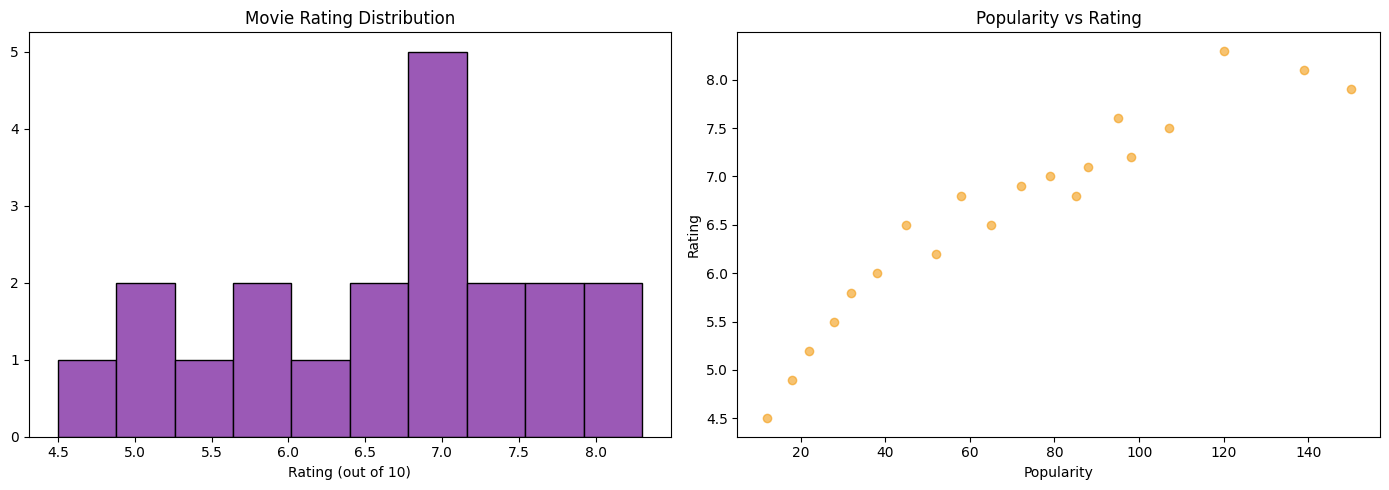

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['vote_average'], bins=10,
             color='#9b59b6', edgecolor='black')
axes[0].set_title('Movie Rating Distribution')
axes[0].set_xlabel('Rating (out of 10)')

axes[1].scatter(df['popularity'], df['vote_average'],
                alpha=0.6, color='#f39c12')
axes[1].set_title('Popularity vs Rating')
axes[1].set_xlabel('Popularity')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

In [6]:
X = df[['budget', 'popularity', 'runtime', 'vote_count', 'revenue']]
y = df['vote_average']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16
Testing samples: 4


In [7]:
# Model 1: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

# Model 2: Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)

print(f"🌲 Random Forest R2 Score:     {rf_r2*100:.2f}%")
print(f"🚀 Gradient Boosting R2 Score: {gb_r2*100:.2f}%")

🌲 Random Forest R2 Score:     99.05%
🚀 Gradient Boosting R2 Score: 96.66%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


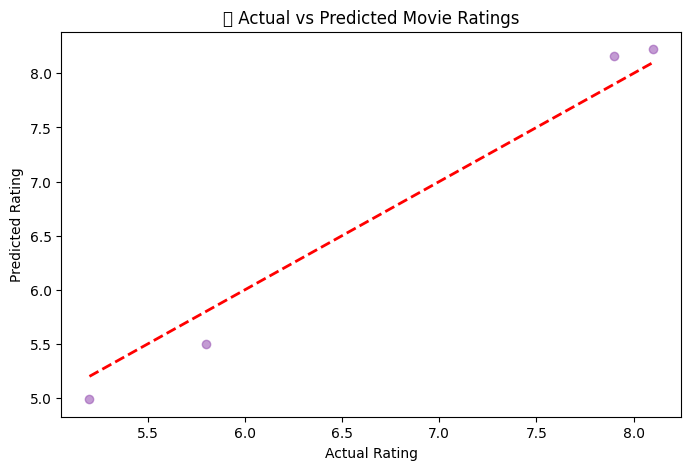

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, gb_pred, alpha=0.6, color='#9b59b6')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('🎬 Actual vs Predicted Movie Ratings')
plt.show()

/tmp/ipykernel_2776/3426209330.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


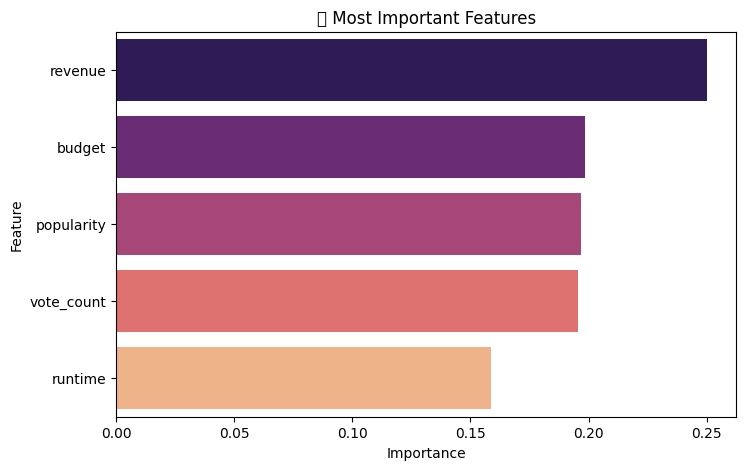

In [9]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance, palette='magma')
plt.title('🔑 Most Important Features')
plt.show()

In [10]:
new_movie = pd.DataFrame({
    'budget':     [50000000],
    'popularity': [50.0],
    'runtime':    [120.0],
    'vote_count': [1000],
    'revenue':    [150000000]
})

predicted_rating = gb_model.predict(new_movie)
print(f"🎬 Predicted Movie Rating: {predicted_rating[0]:.1f} / 10")

🎬 Predicted Movie Rating: 6.1 / 10
